In [1]:
import os
import glob
import random

import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler

import matplotlib.pyplot as plt
from monai.losses import DiceLoss

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [3]:
class InceptionBlock(nn.Module):
    def __init__(self, in_ch, out_ch, batch_norm=False, residual=False):
        super().__init__()
        self.batch_norm = batch_norm
        self.residual   = residual

        self.branch1 = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        self.branch2 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.branch3 = nn.Conv2d(in_ch, out_ch, kernel_size=5, padding=2)
        self.branch4 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)

        if batch_norm:
            self.bn1 = nn.BatchNorm2d(out_ch)
            self.bn2 = nn.BatchNorm2d(out_ch)
            self.bn3 = nn.BatchNorm2d(out_ch)
            self.bn4 = nn.BatchNorm2d(in_ch)

        self.conv_linear = nn.Conv2d(out_ch*3 + in_ch, out_ch, kernel_size=1)
        if batch_norm:
            self.bn_linear = nn.BatchNorm2d(out_ch)

        if residual:
            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1)
            if batch_norm:
                self.bn_sc = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        b1 = F.relu(self.bn1(self.branch1(x))) if self.batch_norm else F.relu(self.branch1(x))
        b2 = F.relu(self.bn2(self.branch2(x))) if self.batch_norm else F.relu(self.branch2(x))
        b3 = F.relu(self.bn3(self.branch3(x))) if self.batch_norm else F.relu(self.branch3(x))
        b4 = self.branch4(x)
        if self.batch_norm: b4 = F.relu(self.bn4(b4))

        merged = torch.cat([b1, b2, b3, b4], dim=1)
        out = self.conv_linear(merged)
        if self.batch_norm: out = self.bn_linear(out)
        out = F.relu(out)

        if self.residual:
            sc = self.shortcut(x)
            if self.batch_norm: sc = self.bn_sc(sc)
            out = out + sc
        return out


In [4]:
class IUNet(nn.Module):
    def __init__(self, in_ch=1, base_filters=16, dropout=0.1, batch_norm=True, residual=True):
        super().__init__()
        self.enc1 = InceptionBlock(in_ch, base_filters, batch_norm, residual)
        self.pool1, self.drop1 = nn.MaxPool2d(2), nn.Dropout2d(dropout)

        self.enc2 = InceptionBlock(base_filters, base_filters*2, batch_norm, residual)
        self.pool2, self.drop2 = nn.MaxPool2d(2), nn.Dropout2d(dropout)

        self.enc3 = InceptionBlock(base_filters*2, base_filters*4, batch_norm, residual)
        self.pool3, self.drop3 = nn.MaxPool2d(2), nn.Dropout2d(dropout)

        self.enc4 = InceptionBlock(base_filters*4, base_filters*8, batch_norm, residual)
        self.pool4, self.drop4 = nn.MaxPool2d(2), nn.Dropout2d(dropout)

        self.bottleneck = InceptionBlock(base_filters*8, base_filters*16, batch_norm, residual)
        self.dropb       = nn.Dropout2d(dropout*1.5)

        # decoder
        self.up4 = nn.ConvTranspose2d(base_filters*16, base_filters*8, 2, 2)
        self.dec4 = InceptionBlock(base_filters*16, base_filters*8, batch_norm, residual)

        self.up3 = nn.ConvTranspose2d(base_filters*8, base_filters*4, 2, 2)
        self.dec3 = InceptionBlock(base_filters*8, base_filters*4, batch_norm, residual)

        self.up2 = nn.ConvTranspose2d(base_filters*4, base_filters*2, 2, 2)
        self.dec2 = InceptionBlock(base_filters*4, base_filters*2, batch_norm, residual)

        self.up1 = nn.ConvTranspose2d(base_filters*2, base_filters, 2, 2)
        self.dec1 = InceptionBlock(base_filters*2, base_filters, batch_norm, residual)

        self.out_conv = nn.Conv2d(base_filters, 1, 1)

    def forward(self, x):
        c1 = self.enc1(x); p1 = self.drop1(self.pool1(c1))
        c2 = self.enc2(p1); p2 = self.drop2(self.pool2(c2))
        c3 = self.enc3(p2); p3 = self.drop3(self.pool3(c3))
        c4 = self.enc4(p3); p4 = self.drop4(self.pool4(c4))

        bn = self.dropb(self.bottleneck(p4))

        u4 = self.up4(bn); d4 = self.dec4(torch.cat([u4, c4], dim=1))
        u3 = self.up3(d4); d3 = self.dec3(torch.cat([u3, c3], dim=1))
        u2 = self.up2(d3); d2 = self.dec2(torch.cat([u2, c2], dim=1))
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([u1, c1], dim=1))

        return self.out_conv(d1)

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, folder, img_size=(128,128), augment=False):
        all_imgs = sorted(glob.glob(os.path.join(folder, '*.tif')))
        self.samples = []
        for img_path in all_imgs:
            base, ext = os.path.splitext(img_path)
            mask_path = base + '_mask' + ext
            if os.path.exists(mask_path):
                self.samples.append((img_path, mask_path))
        if not self.samples:
            raise RuntimeError(f"No image/mask pairs in {folder}")

        self.img_size = img_size
        self.augment  = augment
        self.clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        img  = cv2.resize(img,  self.img_size)
        mask = cv2.resize(mask, self.img_size)

        # CLAHE + normalize
        img  = self.clahe.apply(img) / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.augment:
            # flip
            if random.random() < 0.5:
                img, mask = np.fliplr(img), np.fliplr(mask)
            # rotate ±15°
            angle = random.uniform(-15,15)
            M = cv2.getRotationMatrix2D((self.img_size[0]//2, self.img_size[1]//2), angle, 1)
            img  = cv2.warpAffine(img,  M, self.img_size)
            mask = cv2.warpAffine(mask, M, self.img_size)
            # gaussian noise
            img  = np.clip(img + np.random.randn(*img.shape)*0.05, 0, 1)

        img  = torch.from_numpy(img).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask


In [6]:
def make_splits(dataset, train_frac=0.7, val_frac=0.2, seed=42):
    N = len(dataset)
    n_train = int(N*train_frac)
    n_val   = int(N*val_frac)
    n_test  = N - n_train - n_val
    return random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

In [7]:
def get_loaders(base_folder, batch_size=8):
    ds_full = SegmentationDataset(base_folder, augment=False)
    ds_train, ds_val, ds_test = make_splits(ds_full)
    ds_train.dataset.augment = True

    return {
        'train': DataLoader(ds_train, batch_size=batch_size, shuffle=True, pin_memory=True),
        'val':   DataLoader(ds_val,   batch_size=batch_size, shuffle=False, pin_memory=True),
        'test':  DataLoader(ds_test,  batch_size=batch_size, shuffle=False, pin_memory=True),
    }

In [8]:
def batch_dice_coeff(logits, targets, threshold=0.5, eps=1e-6):
    targets = targets.to(logits.device)
    probs   = torch.sigmoid(logits)
    preds   = (probs > threshold).float()
    inter   = (preds*targets).sum(dim=(1,2,3))
    union   = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    return ((2*inter+eps)/(union+eps)).mean().item()



In [9]:
def run_experiment_onecycle(name, base_folder,
                            num_epochs=50, max_lr=1e-3,
                            base_filters=16, early_stop=10):

    # Data
    loaders = get_loaders(base_folder, batch_size=8)
    n_steps = len(loaders['train'])

    # Model, optimizer, mixed‐precision
    model     = IUNet(base_filters=base_filters).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=max_lr)
    scaler    = GradScaler()

    # One-Cycle scheduler
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=n_steps,
        epochs=num_epochs,
        pct_start=0.3,        # 30% warm-up
        div_factor=25.0,      # initial_lr = max_lr/div_factor
        final_div_factor=1e4, # min_lr = initial_lr/final_div_factor
    )

    bce_loss  = nn.BCEWithLogitsLoss()
    dice_loss = DiceLoss(sigmoid=True, reduction='mean')
    history   = {k: [] for k in ['train_loss','val_loss','test_loss',
                                 'train_dice','val_dice','test_dice']}
    best_val, wait = float('inf'), 0

    for epoch in range(1, num_epochs+1):
        # — Train —
        model.train()
        tloss, tdice = 0.0, 0.0
        for x,y in tqdm(loaders['train'], desc=f"{name} Train E{epoch:02d}"):
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast():
                out  = model(x)
                loss = bce_loss(out, y) + dice_loss(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()    # <-- one-cycle step per batch

            tloss += loss.item()
            tdice += batch_dice_coeff(out, y)

        history['train_loss'].append(tloss / n_steps)
        history['train_dice'].append(tdice / n_steps)

        model.eval()
        for split in ['val','test']:
            sloss, sdice = 0.0, 0.0
            loader = loaders[split]
            with torch.no_grad():
                for x,y in loader:
                    x,y = x.to(device), y.to(device)
                    out  = model(x)
                    loss = bce_loss(out, y) + dice_loss(out, y)
                    sloss += loss.item()
                    sdice += batch_dice_coeff(out, y)
            history[f'{split}_loss'].append(sloss / len(loader))
            history[f'{split}_dice'].append(sdice / len(loader))

        # Early stopping on val loss
        val = history['val_loss'][-1]
        if val < best_val:
            best_val, wait = val, 0
            torch.save(model.state_dict(), f"best_{name}.pth")
        else:
            wait += 1
            if wait >= early_stop:
                print(f"Early stopping at epoch {epoch}")
                break

        print(f"{name} E{epoch:02d} | "
              f"TrL {history['train_loss'][-1]:.4f} "
              f"TrD {history['train_dice'][-1]:.4f} | "
              f"VaL {history['val_loss'][-1]:.4f} "
              f"VaD {history['val_dice'][-1]:.4f}")

    model.load_state_dict(torch.load(f"best_{name}.pth", weights_only=True))
    model.eval()
    test_loss, test_dice = 0.0, 0.0
    with torch.no_grad():
        for x,y in loaders['test']:
            x,y  = x.to(device), y.to(device)
            out  = model(x)
            loss = bce_loss(out, y) + dice_loss(out, y)
            test_loss += loss.item()
            test_dice += batch_dice_coeff(out, y)
    n = len(loaders['test'])
    print(f"{name} Final Test → Loss: {test_loss/n:.4f}, Dice: {test_dice/n:.4f}")

    return history

clahe (/mnt/e/Mahban/Nerve/DL_Spring_2025/ultrasound-nerve-segmentation_clahe/train): 11270 .tif files
filter (/mnt/e/Mahban/Nerve/DL_Spring_2025/ultrasound-nerve-segmentation_2Dfilter/train): 11270 .tif files


/tmp/ipykernel_4558/1634183403.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
clahe Train E01:   0%|                                                                          | 0/493 [00:00<?, ?it/s]/tmp/ipykernel_4558/1634183403.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
clahe Train E01: 100%|████████████████████████████████████████████████████████████████| 493/493 [03:00<00:00,  2.73it/s]


clahe E01 | TrL 1.4467 TrD 0.0760 | VaL 1.3231 VaD 0.2358


clahe Train E02: 100%|████████████████████████████████████████████████████████████████| 493/493 [02:53<00:00,  2.84it/s]


clahe E02 | TrL 1.2802 TrD 0.2581 | VaL 1.2210 VaD 0.2648


...

filter E48 | TrL 0.6981 TrD 0.5993 | VaL 0.7359 VaD 0.5484


filter Train E49: 100%|███████████████████████████████████████████████████████████████| 493/493 [02:43<00:00,  3.01it/s]


filter E49 | TrL 0.6983 TrD 0.5881 | VaL 0.7372 VaD 0.5339


filter Train E50: 100%|███████████████████████████████████████████████████████████████| 493/493 [02:45<00:00,  2.98it/s]


Early stopping at epoch 50
filter Final Test → Loss: 0.7351, Dice: 0.5392


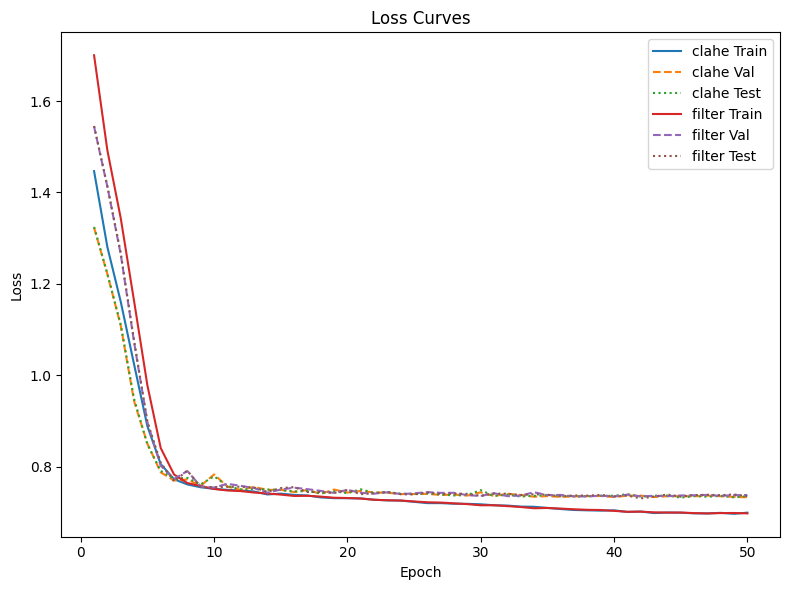

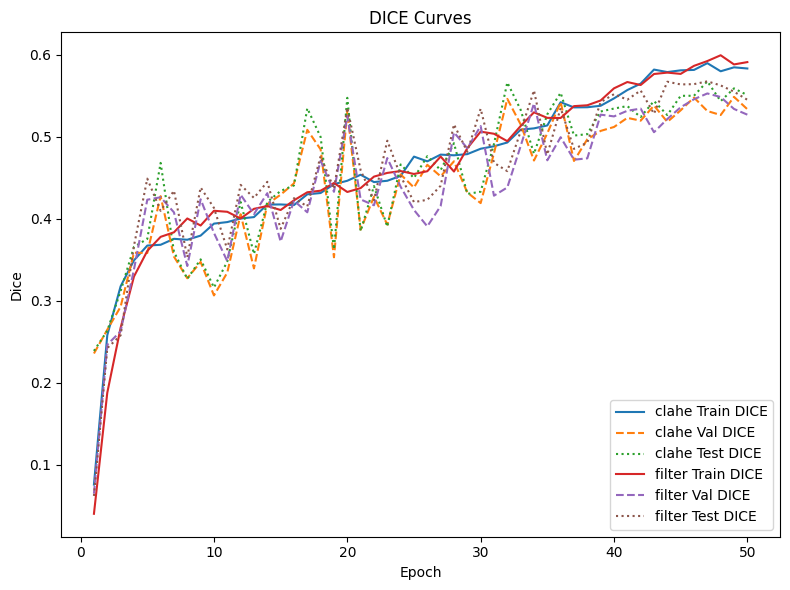

In [16]:
if __name__ == "__main__":
    torch.manual_seed(42)

    experiments = {
        'clahe':  r"/mnt/e/Mahban/Nerve/DL_Spring_2025/ultrasound-nerve-segmentation_clahe/train",
        'filter': r"/mnt/e/Mahban/Nerve/DL_Spring_2025/ultrasound-nerve-segmentation_2Dfilter/train"
    }

    import os

    for name, path in experiments.items():
        files = os.listdir(path)
        print(f"{name} ({path}): {len(files)} .tif files")


    all_hist = {}
    for name, folder in experiments.items():
        all_hist[name] = run_experiment_onecycle(name, folder, num_epochs=50, max_lr=1e-3, base_filters=16,early_stop=10)

    # ── Plotting ─────────────────────────────────────────────────────────────
    epochs = range(1, len(all_hist['clahe']['train_loss'])+1)

    plt.figure(figsize=(8,6))
    for nm in ['clahe','filter']:
        plt.plot(epochs, all_hist[nm]['train_loss'], label=f'{nm} Train')
        plt.plot(epochs, all_hist[nm]['val_loss'],   label=f'{nm} Val', linestyle='--')
        plt.plot(epochs, all_hist[nm]['test_loss'],  label=f'{nm} Test', linestyle=':')
    plt.title('Loss Curves'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,6))
    for nm in ['clahe','filter']:
        plt.plot(epochs, all_hist[nm]['train_dice'], label=f'{nm} Train DICE')
        plt.plot(epochs, all_hist[nm]['val_dice'],   label=f'{nm} Val DICE',   linestyle='--')
        plt.plot(epochs, all_hist[nm]['test_dice'],  label=f'{nm} Test DICE',  linestyle=':')
    plt.title('DICE Curves'); plt.xlabel('Epoch'); plt.ylabel('Dice'); plt.legend(); plt.tight_layout()
    plt.show()